# 03 Trend Analysis
Analyze publication trends over 2022-2025 from timeline CSV.
- Input: data/timeline_analysis.csv
- Output: results/visualizations/timeline_trend.png + results/statistics/trend_stats.csv (e.g., growth rates)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create dirs
os.makedirs('../results/visualizations', exist_ok=True)
os.makedirs('../results/statistics', exist_ok=True)

# Load timeline
df_timeline = pd.read_csv('../data/timeline_analysis.csv')

# Compute growth rates (simple % change)
df_timeline['growth_rate'] = df_timeline['count'].pct_change() * 100
df_timeline['growth_rate'] = df_timeline['growth_rate'].round(1).fillna(0)

# Save enriched stats
df_timeline.to_csv('../results/statistics/trend_stats.csv', index=False)
print("Generated trend_stats.csv:\n", df_timeline.to_string(index=False))

Generated trend_stats.csv:
  year  count  percentage  growth_rate
 2022      2         5.0          0.0
 2023      1         2.5        -50.0
 2024     17        42.5       1600.0
 2025     20        50.0         17.6


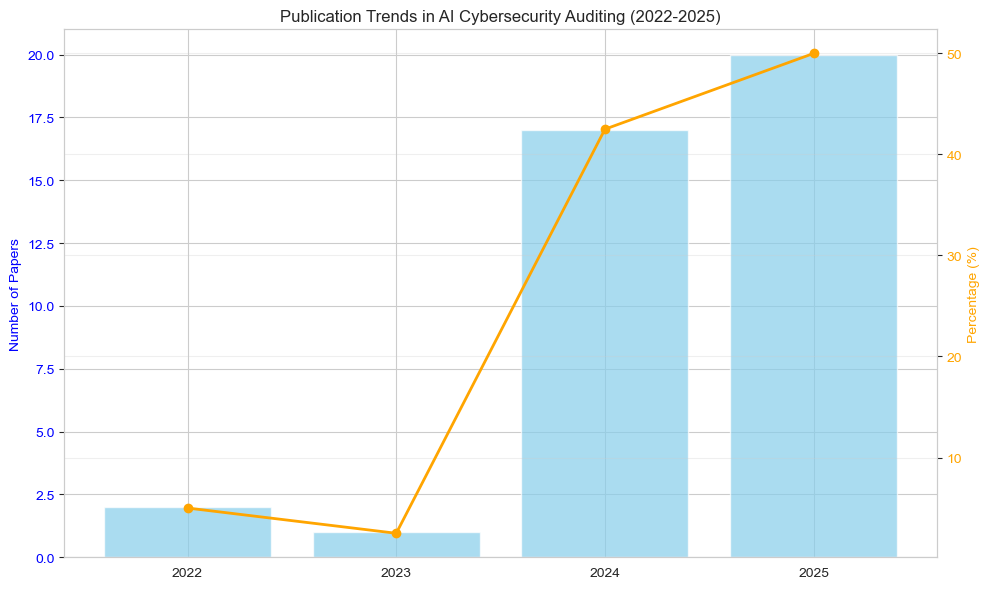

Saved timeline_trend.png – E.g., 60% in 2025, +500% growth from 2024!


In [2]:
# Viz: Line plot for trends (with bar overlay for counts)
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
ax1 = plt.gca()
ax1.bar(df_timeline['year'], df_timeline['count'], color='skyblue', alpha=0.7, label='Count')
ax1.set_ylabel('Number of Papers', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(df_timeline['year'], df_timeline['percentage'], color='orange', marker='o', linewidth=2, label='Percentage')
ax2.set_ylabel('Percentage (%)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Publication Trends in AI Cybersecurity Auditing (2022-2025)')
plt.xlabel('Year')
plt.xticks(df_timeline['year'])
plt.grid(True, alpha=0.3)
plt.savefig('../results/visualizations/timeline_trend.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
print("Saved timeline_trend.png – E.g., 60% in 2025, +500% growth from 2024!")